In [1]:
# [1단계] 재고관리 데이터 불러오기 및 기본 전처리

import pandas as pd
import numpy as np

# 1. CSV 파일 불러오기
# - encoding 오류가 있을 수 있어 utf-8-sig 우선 시도
file_path = r"C:\Users\user\Desktop\inventory_project\data\inventory_data.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# 2. 원본 데이터 복사
# - 혹시 모를 원본 보존용
raw_df = df.copy()

# 3. 날짜 컬럼 변환
# - 현재 '2026. 1. 29' 형태이므로 datetime으로 변환
df['날짜'] = pd.to_datetime(df['날짜'], format='%Y. %m. %d')

# 4. 숫자형으로 바꿔야 하는 컬럼 목록 지정
# - 실제 CSV를 확인했을 때 문자열(object)로 들어온 컬럼들이 있어 정리 필요
numeric_cols = [
    '코업', '포승', '포승이고', '청호', '한라', '진성', '청호이고',
    '해드림', '그린써브케이탑', '본사', '직송',
    '재고합계', '당월출고수량', '직전출고수량',
    '일일소비량', '7일활동소비량', '7일실질소비량',
    '안전재고', '최소재고', '최대재고',
    '긴급발생횟수', '재고_커버리지', '위험점수'
]

# 5. 퍼센트(%) 형태 컬럼 정리
# - '긴급발생비율', '소비_급증률'은 예: '12.50%' 형태일 가능성이 있어 % 제거 후 숫자 변환
percent_cols = ['긴급발생비율', '소비_급증률']

# 6. 숫자형 컬럼 변환
# - 쉼표(,) 제거 후 숫자로 변환
for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

# 7. 퍼센트 컬럼 변환
# - % 제거 후 숫자형으로 변환
for col in percent_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('%', '', regex=False).str.strip(),
        errors='coerce'
    )

# 8. 기본 정보 확인
print("데이터 크기:", df.shape)
print("\n컬럼별 데이터 타입:")
print(df.dtypes)

print("\n결측치 개수:")
print(df.isnull().sum())

print("\n상위 5개 행:")
print(df.head())

# 9. 날짜 범위 확인
print("\n날짜 범위:")
print("시작일:", df['날짜'].min())
print("종료일:", df['날짜'].max())

# 10. 범주형 컬럼 주요 값 확인
print("\n상태 분포:")
print(df['상태'].value_counts(dropna=False))

print("\n위험등급 분포:")
print(df['위험등급'].value_counts(dropna=False))

print("\n유형_분류 분포:")
print(df['유형_분류'].value_counts(dropna=False))

데이터 크기: (4383, 32)

컬럼별 데이터 타입:
날짜         datetime64[us]
품번                  int64
품목군                   str
품목                    str
코업                float64
포승                float64
포승이고              float64
청호                float64
한라                float64
진성                float64
청호이고              float64
해드림               float64
그린써브케이탑           float64
본사                float64
직송                float64
재고합계              float64
당월출고수량            float64
직전출고수량            float64
일일소비량             float64
7일활동소비량           float64
7일실질소비량           float64
안전재고              float64
상태                    str
최소재고              float64
최대재고              float64
긴급발생횟수              int64
긴급발생비율            float64
재고_커버리지           float64
소비_급증률            float64
유형_분류                 str
위험점수              float64
위험등급                  str
dtype: object

결측치 개수:
날짜            0
품번            0
품목군           0
품목            0
코업            0
포승         3508
포승이고       4272
청

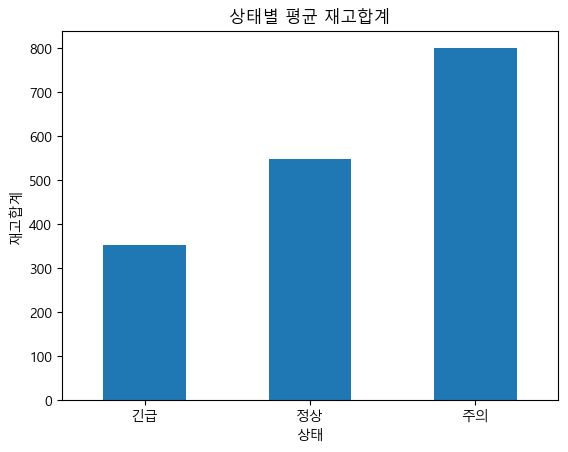

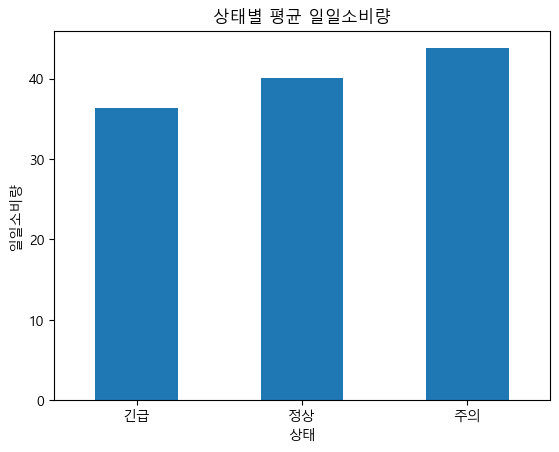

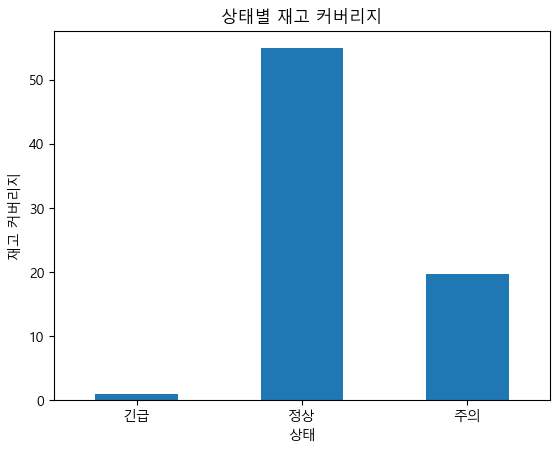

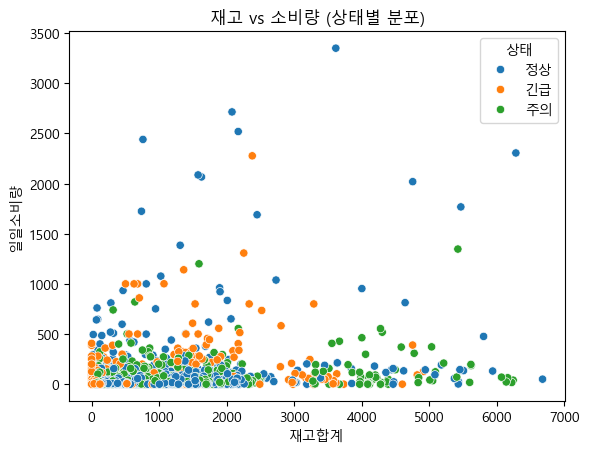

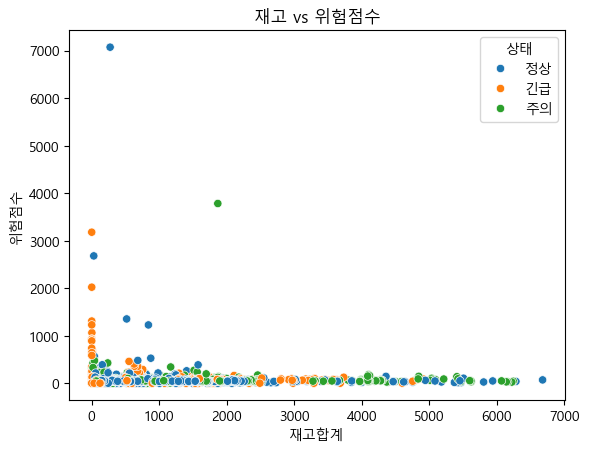

In [2]:
# [2-1단계] 재고 상태 및 위험 구조 시각화

import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'

# 1. 상태별 재고합계 평균
plt.figure()
df.groupby('상태')['재고합계'].mean().plot(kind='bar')
plt.title('상태별 평균 재고합계')
plt.xlabel('상태')
plt.ylabel('재고합계')
plt.xticks(rotation=0)
plt.show()


# 2. 상태별 일일소비량 평균
plt.figure()
df.groupby('상태')['일일소비량'].mean().plot(kind='bar')
plt.title('상태별 평균 일일소비량')
plt.xlabel('상태')
plt.ylabel('일일소비량')
plt.xticks(rotation=0)
plt.show()


# 3. 상태별 재고 커버리지
plt.figure()
df.groupby('상태')['재고_커버리지'].mean().plot(kind='bar')
plt.title('상태별 재고 커버리지')
plt.xlabel('상태')
plt.ylabel('재고 커버리지')
plt.xticks(rotation=0)
plt.show()


# 4. 재고 vs 소비 (핵심 그래프)
plt.figure()
sns.scatterplot(
    data=df,
    x='재고합계',
    y='일일소비량',
    hue='상태'
)
plt.title('재고 vs 소비량 (상태별 분포)')
plt.xticks(rotation=0)
plt.show()


# 5. 위험점수 vs 재고
plt.figure()
sns.scatterplot(
    data=df,
    x='재고합계',
    y='위험점수',
    hue='상태'
)
plt.title('재고 vs 위험점수')
plt.xticks(rotation=0)
plt.show()

In [3]:
# [3단계] 위험 품목 TOP 분석

# 1. 품목별 위험 요약
item_risk = df.groupby(['품번', '품목']).agg({
    '위험점수': 'mean',
    '긴급발생횟수': 'sum',
    '재고합계': 'mean',
    '일일소비량': 'mean',
    '재고_커버리지': 'mean'
}).reset_index()

# 2. 위험도 기준 정렬
top_risk_items = item_risk.sort_values(by='위험점수', ascending=False).head(10)

print("📌 위험 점수 기준 TOP 10 품목")
print(top_risk_items)

📌 위험 점수 기준 TOP 10 품목
       품번                           품목        위험점수  긴급발생횟수         재고합계  \
51  21609              베이킹파우더 플러스 20kg  202.707105      38   229.026316   
92  23962           베이커리 슬라이스 치즈 1.8kg  172.615000     380    69.013158   
6   20905   마리네이티드 세그먼트 토마토 (1/4컷) 1kg  166.938421     266    99.434211   
74  23118  제니코 모짜 슬라이스(냉동) 18g 1kg*3ea  150.137632     608   115.326842   
31  21313           엔젤 인스턴트이스트-저당 10kg  133.796842      38  1930.026316   
2   10405             생이스트 (냉동생지) 500g  118.278158     988    13.661842   
33  21318                  엔젤 이스트엑기스분말  109.832632     798   698.868421   
38  21340               레드스타 생이스트 500g   99.968947     798    53.257895   
86  23143           칼라 체다 프라임 골드 2.5kg   90.047895     342   148.809211   
0   10401                    생이스트 500g   84.101053    1292  1668.227368   

         일일소비량     재고_커버리지  
51   26.394737  108.255000  
92   17.572368   13.664211  
6    23.373684   12.933421  
74   48.596316   49.623684  
31   23.

In [4]:
# [3단계] 위험 품목 분석 (재고 0 품목 제거 포함)

# 1. 평균 재고 0 품목 제거
item_stock = df.groupby('품번')['재고합계'].mean().reset_index()
valid_items = item_stock[item_stock['재고합계'] > 0]['품번']

df_filtered = df[df['품번'].isin(valid_items)]

# 2. 품목별 집계
item_risk = df_filtered.groupby(['품번', '품목']).agg({
    '위험점수': 'mean',
    '긴급발생횟수': 'sum',
    '재고합계': 'mean',
    '일일소비량': 'mean',
    '재고_커버리지': 'mean'
}).reset_index()

# 3. TOP10 추출
top_risk_items = item_risk.sort_values(by='위험점수', ascending=False).head(10)
top_urgent_items = item_risk.sort_values(by='긴급발생횟수', ascending=False).head(10)

# 4. 교집합 (핵심 품목)
top_risk_set = set(top_risk_items['품번'])
top_urgent_set = set(top_urgent_items['품번'])

real_risk_items = top_risk_set.intersection(top_urgent_set)
real_items_df = item_risk[item_risk['품번'].isin(real_risk_items)]

<Figure size 640x480 with 0 Axes>

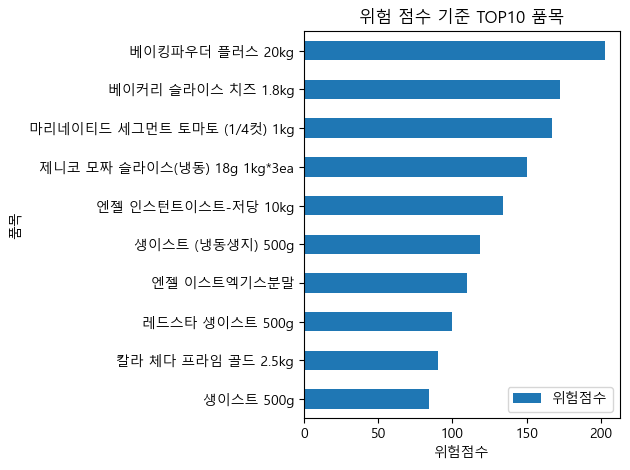

In [5]:
plt.figure()

top_risk_items.sort_values(by='위험점수').plot(
    kind='barh',
    x='품목',
    y='위험점수'
)

plt.title('위험 점수 기준 TOP10 품목')
plt.xlabel('위험점수')
plt.ylabel('품목')

plt.tight_layout()
plt.show()

In [6]:
# [3단계 보완] 긴급 발생 비율 기준 필터링

# 1. 품목별 전체 데이터 수
total_count = df.groupby('품번').size().reset_index(name='전체횟수')

# 2. 긴급 상태 데이터 수
urgent_count = df[df['상태'] == '긴급'].groupby('품번').size().reset_index(name='긴급횟수')

# 3. 결합
urgent_ratio = pd.merge(total_count, urgent_count, on='품번', how='left')
urgent_ratio['긴급횟수'] = urgent_ratio['긴급횟수'].fillna(0)

# 4. 긴급 발생 비율 계산
urgent_ratio['긴급비율'] = urgent_ratio['긴급횟수'] / urgent_ratio['전체횟수']

# 5. 90% 이상 품목 제거
valid_items_ratio = urgent_ratio[urgent_ratio['긴급비율'] < 0.9]['품번']

# 6. 필터링 데이터 생성
df_filtered_final = df[df['품번'].isin(valid_items_ratio)]

print("전체 품목 수:", df['품번'].nunique())
print("필터링 후 품목 수:", df_filtered_final['품번'].nunique())

전체 품목 수: 117
필터링 후 품목 수: 99


<Figure size 640x480 with 0 Axes>

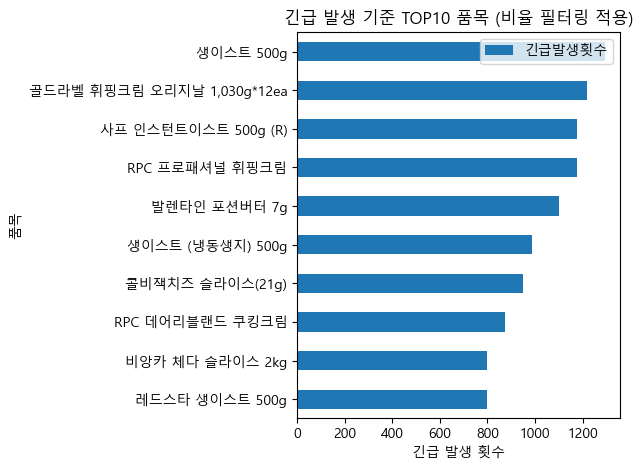

In [7]:
# 필터링된 데이터 기준 집계

item_risk_final = df_filtered_final.groupby(['품번', '품목']).agg({
    '위험점수': 'mean',
    '긴급발생횟수': 'sum',
    '재고합계': 'mean',
    '일일소비량': 'mean',
    '재고_커버리지': 'mean'
}).reset_index()

top_urgent_items_final = item_risk_final.sort_values(by='긴급발생횟수', ascending=False).head(10)


# 그래프
import matplotlib.pyplot as plt

plt.figure()

top_urgent_items_final.sort_values(by='긴급발생횟수').plot(
    kind='barh',
    x='품목',
    y='긴급발생횟수'
)

plt.title('긴급 발생 기준 TOP10 품목 (비율 필터링 적용)')
plt.xlabel('긴급 발생 횟수')
plt.ylabel('품목')

plt.tight_layout()
plt.show()

In [8]:
# [3단계 보완] 핵심 관리 대상 품목 (최종 버전)

# 1. 필터링된 데이터 기준 집계
item_risk_final = df_filtered_final.groupby(['품번', '품목']).agg({
    '위험점수': 'mean',
    '긴급발생횟수': 'sum',
    '재고합계': 'mean',
    '일일소비량': 'mean',
    '재고_커버리지': 'mean'
}).reset_index()

# 2. TOP10 추출
top_risk_items_final = item_risk_final.sort_values(by='위험점수', ascending=False).head(10)
top_urgent_items_final = item_risk_final.sort_values(by='긴급발생횟수', ascending=False).head(10)

# 3. 교집합
top_risk_set = set(top_risk_items_final['품번'])
top_urgent_set = set(top_urgent_items_final['품번'])

real_risk_items_final = top_risk_set.intersection(top_urgent_set)

# 4. 핵심 품목 데이터
real_items_df_final = item_risk_final[item_risk_final['품번'].isin(real_risk_items_final)]

print("핵심 관리 대상 품목 수:", len(real_items_df_final))
print(real_items_df_final[['품번', '품목', '위험점수', '긴급발생횟수']])

핵심 관리 대상 품목 수: 3
       품번                품목        위험점수  긴급발생횟수
0   10401         생이스트 500g   84.101053    1292
1   10405  생이스트 (냉동생지) 500g  118.278158     988
34  21340    레드스타 생이스트 500g   99.968947     798


<Figure size 640x480 with 0 Axes>

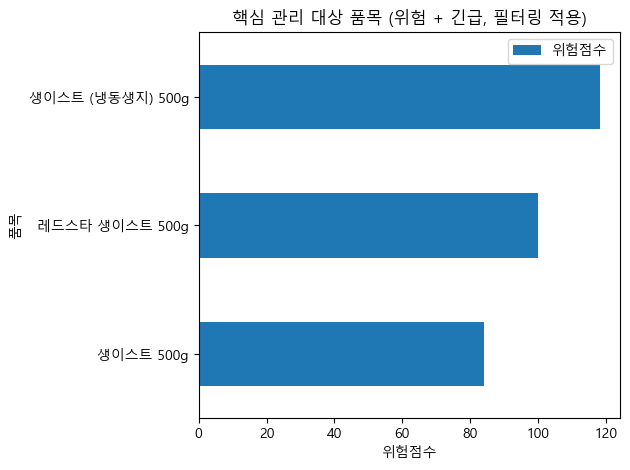

In [9]:
import matplotlib.pyplot as plt

plt.figure()

real_items_df_final.sort_values(by='위험점수').plot(
    kind='barh',
    x='품목',
    y='위험점수'
)

plt.title('핵심 관리 대상 품목 (위험 + 긴급, 필터링 적용)')
plt.xlabel('위험점수')
plt.ylabel('품목')

plt.tight_layout()
plt.show()

In [11]:
# [전략1] 안전재고 재설정

# 소비 기반 안전재고 (7일 평균 소비 기준)
df_filtered_final['안전재고_개선'] = df_filtered_final['7일실질소비량'] * 2

# 기존 vs 개선 비교
compare_stock = df_filtered_final[['품번', '품목', '안전재고', '안전재고_개선']].head(20)

print(compare_stock)

       품번                   품목  안전재고  안전재고_개선
0   10401            생이스트 500g   0.0     0.00
2   10405     생이스트 (냉동생지) 500g   0.0    24.58
3   10714      제니코 인스턴트이스트 5kg   0.0    34.86
5   21323       글로리팡 생이스트 500g   0.0   492.58
6   21347    글로리팡 생이스트 벌크 20kg   0.0   217.14
7   21340       레드스타 생이스트 500g   0.0    97.68
8   21343    레드스타 생이스트 벌크 10kg   0.0   697.14
9   21501   냉동건조효모 (하이론댈) 골드라벨   0.0   719.64
10  21502        냉동건조효모 (하이론댈)   0.0   170.78
11  21301  사프 인스턴트이스트 500g (R)   0.0   957.06
12  21302  사프 인스턴트이스트 500g (G)   0.0   775.48
13  21303  사프 인스턴트이스트 125g (R)   0.0    44.86
14  21305  사프 인스턴트이스트 10kg (R)   0.0   214.58
16  21329         사프 트레디지 400g   0.0     1.42
17  21332       리벤도 비디100 500g   0.0     0.28
18  21311   엔젤 인스턴트이스트-고당 500g   0.0    99.38
19  21312   엔젤 인스턴트이스트-저당 500g   0.0   176.84
20  21313   엔젤 인스턴트이스트-저당 10kg   0.0    57.42
22  21318          엔젤 이스트엑기스분말   0.0    20.28
23  10605              불활성건조효모   0.0    32.22


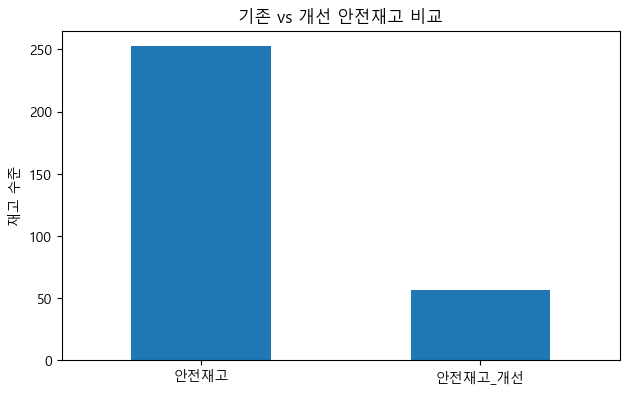

In [15]:
# 기존 vs 개선 안전재고 비교

plt.figure()

df_filtered_final[['안전재고', '안전재고_개선']].mean().plot(kind='bar')

plt.title('기존 vs 개선 안전재고 비교')
plt.ylabel('재고 수준')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

In [17]:
# [전략2] 긴급 사전 감지

df_filtered_final['위험_예측'] = df_filtered_final['재고합계'] / df_filtered_final['안전재고_개선']

# 위험 기준 설정
df_filtered_final['위험_알림'] = df_filtered_final['위험_예측'].apply(
    lambda x: '경고' if x < 0.5 else '주의' if x < 1 else '정상'
)

df_filtered_final[['품번', '품목', '위험_예측', '위험_알림']].head(20)

,품번,품목,위험_예측,위험_알림
0,10401,생이스트 500g,inf,정상
2,10405,생이스트 (냉동생지) 500g,0.081367,경고
3,10714,제니코 인스턴트이스트 5kg,3.133964,정상
5,21323,글로리팡 생이스트 500g,1.498031,정상
6,21347,글로리팡 생이스트 벌크 20kg,0.368426,경고
7,21340,레드스타 생이스트 500g,0.982801,주의
8,21343,레드스타 생이스트 벌크 10kg,1.090168,정상
9,21501,냉동건조효모 (하이론댈) 골드라벨,3.016786,정상
10,21502,냉동건조효모 (하이론댈),2.640824,정상
11,21301,사프 인스턴트이스트 500g (R),3.778603,정상


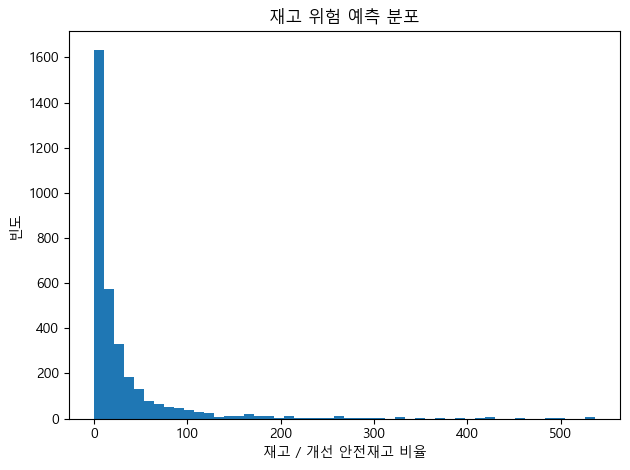

In [22]:
# [전략2-보완] 위험 예측 분포 그래프 오류 해결

import numpy as np
import matplotlib.pyplot as plt

# 1. 위험 예측값 생성
df_filtered_final['위험_예측'] = df_filtered_final['재고합계'] / df_filtered_final['안전재고_개선']

# 2. inf, -inf 값을 NaN으로 변환
df_filtered_final['위험_예측'] = df_filtered_final['위험_예측'].replace([np.inf, -np.inf], np.nan)

# 3. 결측치 제거
risk_pred_clean = df_filtered_final['위험_예측'].dropna()

# 4. 필요 시 극단치 제거 (선택)
# 너무 큰 값이 있으면 그래프가 찌그러질 수 있어서 상위 99%까지만 사용
upper_limit = risk_pred_clean.quantile(0.99)
risk_pred_clean = risk_pred_clean[risk_pred_clean <= upper_limit]

# 5. 히스토그램 시각화
plt.figure()
risk_pred_clean.plot(kind='hist', bins=50)

plt.title('재고 위험 예측 분포')
plt.xlabel('재고 / 개선 안전재고 비율')
plt.ylabel('빈도')

plt.tight_layout()
plt.show()

In [13]:
# [전략3] 핵심 품목 집중 관리

priority_items = real_items_df_final['품번']

df_filtered_final['관리우선순위'] = df_filtered_final['품번'].apply(
    lambda x: '핵심관리' if x in list(priority_items) else '일반관리'
)

df_filtered_final[['품번', '품목', '관리우선순위']].drop_duplicates().head(20)

,품번,품목,관리우선순위
0,10401,생이스트 500g,핵심관리
2,10405,생이스트 (냉동생지) 500g,핵심관리
3,10714,제니코 인스턴트이스트 5kg,일반관리
5,21323,글로리팡 생이스트 500g,일반관리
6,21347,글로리팡 생이스트 벌크 20kg,일반관리
7,21340,레드스타 생이스트 500g,핵심관리
8,21343,레드스타 생이스트 벌크 10kg,일반관리
9,21501,냉동건조효모 (하이론댈) 골드라벨,일반관리
10,21502,냉동건조효모 (하이론댈),일반관리
11,21301,사프 인스턴트이스트 500g (R),일반관리


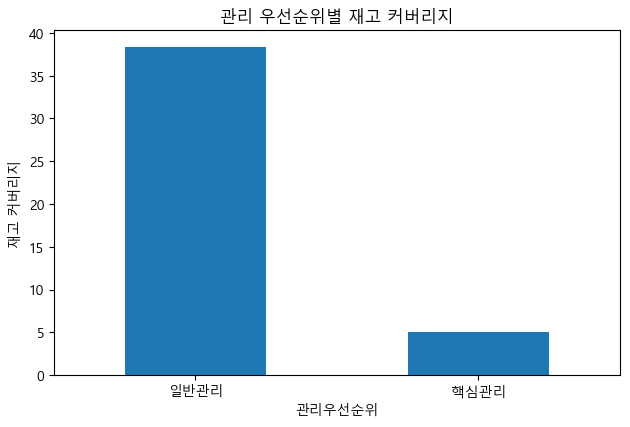

In [21]:
# 관리 우선순위별 재고 비교

plt.figure()

df_filtered_final.groupby('관리우선순위')['재고_커버리지'].mean().plot(kind='bar')

plt.title('관리 우선순위별 재고 커버리지')
plt.ylabel('재고 커버리지')

plt.tight_layout()
plt.xticks(rotation=0)
plt.show()